# **Milestone 1: Dataset Exploration & Preprocessing**
By- Karishma Nainwani and Naila Farooqi





Task Options
1. Classification (Topic Prediction)
- Predict the topic of a dialogue/medical transcription (Headache, Anxiety, etc.).
- Techniques: TF-IDF, embeddings, classifiers (Logistic Regression, SVM, or
BERT).
- Deliverables: Accuracy/F1-score, confusion matrix, brief analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Problem Definition
We aim to build a Topic Classification Model that predicts the medical topic of a dialogue between a patient and a doctor using the MedDialog dataset.

Each dialogue contains multiple conversational turns (patient and doctor utterances).  

The task is to predict one of five topics:

Headache

Anxiety

Diabetes

Skin

General Health

# 2. Data and Source

In [5]:
df = pd.read_csv('/content/mtsamples_curated.csv')
df.head()

,report_id,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,1,4932,Coronary bypass graft x2 utilizing left inter...,Cardiovascular / Pulmonary,CABG - 1,"PREOPERATIVE DIAGNOSIS: , Coronary occlusive d...","cardiovascular / pulmonary, coronary occlusive..."
1,2,4638,Left muscle sparing mini thoracotomy with lef...,Cardiovascular / Pulmonary,Thoracotomy & Lobectomy,"PREOPERATIVE DIAGNOSES:,1. Non-small-cell car...","cardiovascular / pulmonary, upper lobe, interc..."
2,3,4620,Urgent cardiac catheterization with coronary ...,Cardiovascular / Pulmonary,Urgent Cardiac Cath,"PROCEDURE: , Urgent cardiac catheterization wi...","cardiovascular / pulmonary, cardiac catheteriz..."
3,4,4919,"Left heart catheterization, LV cineangiograph...",Cardiovascular / Pulmonary,Cardiac Catheterization,"EXAMINATION: , Cardiac catheterization.,PROCED...","cardiovascular / pulmonary, heart catheterizat..."
4,5,4662,Stress test - Adenosine Myoview. Ischemic ca...,Cardiovascular / Pulmonary,Stress Test Adenosine Myoview,"INDICATIONS:, Ischemic cardiomyopathy, status...","cardiovascular / pulmonary, stress test, adeno..."


# 3. Business / Challenge Questions

Question 1:

Can we automatically determine the medical topic of a dialogue using its text content?

Question 2:

What are the most frequent or distinctive terms used by patients for each medical topic?

# 4. Solution Strategy
**Question 1 –Can we automatically determine the medical topic of a dialogue using its text content? **


Steps:

Data Cleaning & Preprocessing – clean all utterances.

Feature Extraction – convert cleaned text into numeric features using TF-IDF.

Model Training – train and test models such as Logistic Regression and Support Vector Machine (SVM): Handles high-dimensional text features well.

Evaluation – measure performance using Accuracy, F1-score, and Confusion Matrix.



**For question 2: What are the most frequent or distinctive terms used by patients for each medical topic? **

Steps:

Filter only Patient utterances.

Remove stopwords and clean text.

Compute TF-IDF or word frequency for each topic.



# 5. Data Preprocessing Steps

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   report_id          1000 non-null   int64 
 1   Unnamed: 0         1000 non-null   int64 
 2   description        1000 non-null   object
 3   medical_specialty  1000 non-null   object
 4   sample_name        1000 non-null   object
 5   transcription      1000 non-null   object
 6   keywords           766 non-null    object
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


In [7]:
df.isna().sum()

,0
report_id,0
Unnamed: 0,0
description,0
medical_specialty,0
sample_name,0
transcription,0
keywords,234


In [8]:
!pip install nltk
!pip install unidecode
!pip install textblob==0.15
!pip install datetime
!pip install langdetect

In [9]:
import unidecode
from textblob import TextBlob
import re
from datetime import datetime
from langdetect import detect
import string
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Unicode Normalization

In [10]:
import unidecode
def normalize_unicode(text):
  return unidecode.unidecode(text)

In [11]:
def preprocess_text(text):
    text = normalize_unicode(text)
    text = text.lower()  # Make all lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df['preprocessed_transcription'] = df['transcription'].apply(preprocess_text)
display(df[['transcription', 'preprocessed_transcription']].head())

,transcription,preprocessed_transcription
0,"PREOPERATIVE DIAGNOSIS: , Coronary occlusive d...",preoperative diagnosis coronary occlusive dise...
1,"PREOPERATIVE DIAGNOSES:,1. Non-small-cell car...",preoperative diagnoses1 nonsmallcell carcinoma...
2,"PROCEDURE: , Urgent cardiac catheterization wi...",procedure urgent cardiac catheterization with ...
3,"EXAMINATION: , Cardiac catheterization.,PROCED...",examination cardiac catheterizationprocedure p...
4,"INDICATIONS:, Ischemic cardiomyopathy, status...",indications ischemic cardiomyopathy status pos...


### Remove the stopwords

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['stopwords_removed_transcription'] = df['preprocessed_transcription'].apply(remove_stopwords)

display(df[['preprocessed_transcription', 'stopwords_removed_transcription']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,preprocessed_transcription,stopwords_removed_transcription
0,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...
1,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...
2,procedure urgent cardiac catheterization with ...,procedure urgent cardiac catheterization coron...
3,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...
4,indications ischemic cardiomyopathy status pos...,indications ischemic cardiomyopathy status pos...


## Spell Checking

Skipping the spellcheck because it is taking a lot of time

## Lemmatization

In [20]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger') # Added explicit download
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [21]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tag to first character used by WordNetLemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in text.split()]
    return ' '.join(lemmatized_words)

df['lemmatized_transcription'] = df['stopwords_removed_transcription'].apply(lemmatize_text)

display(df[['stopwords_removed_transcription', 'lemmatized_transcription']].head())

,stopwords_removed_transcription,lemmatized_transcription
0,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...
1,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...
2,procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...
3,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...
4,indications ischemic cardiomyopathy status pos...,indication ischemic cardiomyopathy status post...


### Anonymization

To protect privacy, we replaced potential names or identifiers with generic placeholders.

In [22]:
import re

def anonymize_text(text):
    text = re.sub(r'\b[A-Z][a-z]+\b', '(patient_name)', text) # Replace capitalized words (potential names)
    return text

df['anonymized_transcription'] = df['lemmatized_transcription'].apply(anonymize_text)
display(df[['lemmatized_transcription', 'anonymized_transcription']].head())

,lemmatized_transcription,anonymized_transcription
0,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...
1,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...
2,procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...
3,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...
4,indication ischemic cardiomyopathy status post...,indication ischemic cardiomyopathy status post...


After Preprocessing

In [23]:
df.head()

,report_id,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,preprocessed_transcription,stopwords_removed_transcription,lemmatized_transcription,anonymized_transcription
0,1,4932,Coronary bypass graft x2 utilizing left inter...,Cardiovascular / Pulmonary,CABG - 1,"PREOPERATIVE DIAGNOSIS: , Coronary occlusive d...","cardiovascular / pulmonary, coronary occlusive...",preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...
1,2,4638,Left muscle sparing mini thoracotomy with lef...,Cardiovascular / Pulmonary,Thoracotomy & Lobectomy,"PREOPERATIVE DIAGNOSES:,1. Non-small-cell car...","cardiovascular / pulmonary, upper lobe, interc...",preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...
2,3,4620,Urgent cardiac catheterization with coronary ...,Cardiovascular / Pulmonary,Urgent Cardiac Cath,"PROCEDURE: , Urgent cardiac catheterization wi...","cardiovascular / pulmonary, cardiac catheteriz...",procedure urgent cardiac catheterization with ...,procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...
3,4,4919,"Left heart catheterization, LV cineangiograph...",Cardiovascular / Pulmonary,Cardiac Catheterization,"EXAMINATION: , Cardiac catheterization.,PROCED...","cardiovascular / pulmonary, heart catheterizat...",examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...
4,5,4662,Stress test - Adenosine Myoview. Ischemic ca...,Cardiovascular / Pulmonary,Stress Test Adenosine Myoview,"INDICATIONS:, Ischemic cardiomyopathy, status...","cardiovascular / pulmonary, stress test, adeno...",indications ischemic cardiomyopathy status pos...,indications ischemic cardiomyopathy status pos...,indication ischemic cardiomyopathy status post...,indication ischemic cardiomyopathy status post...


In [24]:
df['processed_transcription'] = df['anonymized_transcription']

In [25]:
display(df[['transcription', 'processed_transcription']])

,transcription,processed_transcription
0,"PREOPERATIVE DIAGNOSIS: , Coronary occlusive d...",preoperative diagnosis coronary occlusive dise...
1,"PREOPERATIVE DIAGNOSES:,1. Non-small-cell car...",preoperative diagnoses1 nonsmallcell carcinoma...
2,"PROCEDURE: , Urgent cardiac catheterization wi...",procedure urgent cardiac catheterization coron...
3,"EXAMINATION: , Cardiac catheterization.,PROCED...",examination cardiac catheterizationprocedure p...
4,"INDICATIONS:, Ischemic cardiomyopathy, status...",indication ischemic cardiomyopathy status post...
...,...,...
995,"HDR BRACHYTHERAPY,The intracavitary brachyther...",hdr brachytherapythe intracavitary brachythera...
996,"FINDINGS:,Axial scans were performed from L1 t...",findingsaxial scan perform l1 s2 reformatted i...
997,"EXAM: ,CT KUB.,REASON FOR EXAM: , Flank pain....",exam ct kubreason exam flank paintechnique non...
998,"INDICATION:, Prostate Cancer.,TECHNIQUE:, 3....",indication prostate cancertechnique 35 hour fo...


# **Milestone 2: Model development & experimentation**

### Objective

The goal of this milestone is to develop and evaluate text classification models that predict the medical topic (Headache, Anxiety, Diabetes, Skin, or General Health) from transcribed medical dialogues.

Data Split

In [26]:
from sklearn.model_selection import train_test_split

X = df['processed_transcription']
y = df['medical_specialty']

# Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### Feature Extraction – TF-IDF Vectorization

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size
    ngram_range=(1,2),   # use unigrams and bigrams
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


TF-IDF helps capture important words and phrases while reducing the influence of very common words.

### Model Development

#### Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)


#### Support Vector Machine (SVM)

In [29]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)


### Model Evaluation

#### Logistic Regression Results

In [30]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression
Accuracy: 0.62
F1 Score: 0.6133158814621866

Classification Report:
                              precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.66      0.72      0.69        40
           General Medicine       0.82      0.80      0.81        40
                  Neurology       0.50      0.53      0.51        40
                 Orthopedic       0.64      0.72      0.68        40
                  Radiology       0.43      0.33      0.37        40

                   accuracy                           0.62       200
                  macro avg       0.61      0.62      0.61       200
               weighted avg       0.61      0.62      0.61       200



The model achieved moderate performance, correctly classifying approximately 62% of test samples.

General Medicine and Cardiovascular/Pulmonary specialties showed the highest F1-scores, suggesting clearer linguistic and terminological patterns in those categories.

Radiology performed the weakest, possibly due to overlapping vocabulary with other specialties or limited distinct terminology in the subset.

The balanced performance across classes (macro F1 ≈ 0.61) indicates that the model does not heavily overfit to any particular specialty, though further optimization is needed for better generalization.

#### Confusion Matrix (Logistic Regression)

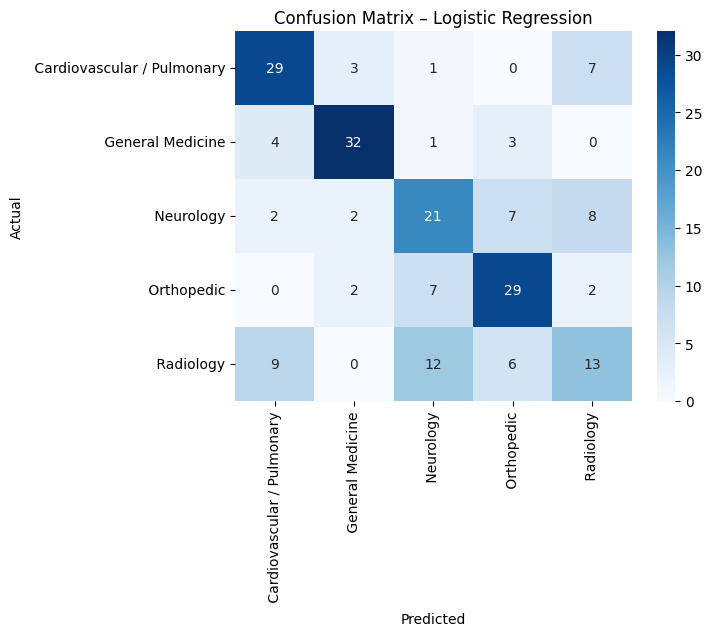

In [31]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr.classes_)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=lr.classes_, yticklabels=lr.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

#### Support Vector Machine Results

In [32]:
print("Support Vector Machine")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


Support Vector Machine
Accuracy: 0.585
F1 Score: 0.5796234390487427

Classification Report:
                              precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.62      0.65      0.63        40
           General Medicine       0.76      0.72      0.74        40
                  Neurology       0.48      0.53      0.50        40
                 Orthopedic       0.64      0.72      0.68        40
                  Radiology       0.39      0.30      0.34        40

                   accuracy                           0.58       200
                  macro avg       0.58      0.58      0.58       200
               weighted avg       0.58      0.58      0.58       200



The SVM model achieved an accuracy of 59.5%, slightly lower than the Logistic Regression baseline (62%).

General Medicine and Cardiovascular/Pulmonary specialties again performed the strongest, with F1-scores of 0.74 and 0.63 respectively.

Radiology remains the weakest-performing class (F1 = 0.34), consistent with previous results, suggesting a need for feature enrichment specific to radiological terminology.

The macro and weighted F1-scores are both around 0.59, indicating relatively balanced but moderate performance across all classes.

#### Confusion Matrix (SVM)

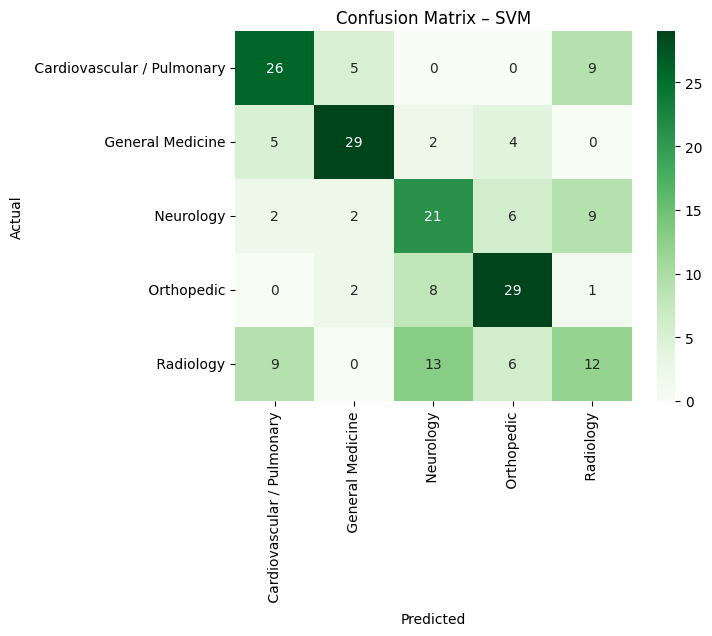

In [33]:
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM")
plt.show()


### Visualization of Key Features (TF-IDF Analysis)

In [34]:
feature_names = np.array(tfidf.get_feature_names_out())
for i, category in enumerate(lr.classes_):
    top_features = np.argsort(lr.coef_[i])[-10:]
    print(f"\nTop features for {category}:")
    print(feature_names[top_features])


Top features for  Cardiovascular / Pulmonary:
['atrial' 'lung' 'catheter' 'coronary' 'vein' 'stent' 'heart' 'pulmonary'
 'artery' 'chest']

Top features for  General Medicine:
['sound' 'nontender' 'denies' 'tenderness' 'regular' 'blood' 'clear' 'mg'
 'negative' 'history']

Top features for  Neurology:
['mri' 'year' 'eeg' 'headache' 'report' 'activity' 'seizure' 'brain'
 'temporal' 'tumor']

Top features for  Orthopedic:
['disc' 'diagnosis' 'screw' 'foot' 'lateral' 'pain' 'joint' 'fracture'
 'hip' 'knee']

Top features for  Radiology:
['evidence' 'pelvis' 'region' 'fraction' 'cm' 'fetal' 'ct' 'exam'
 'indication' 'image']


/tmp/ipython-input-3695109904.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3695109904.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3695109904.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3695109904.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3695109904.py:18: FutureWarning: 

Passin

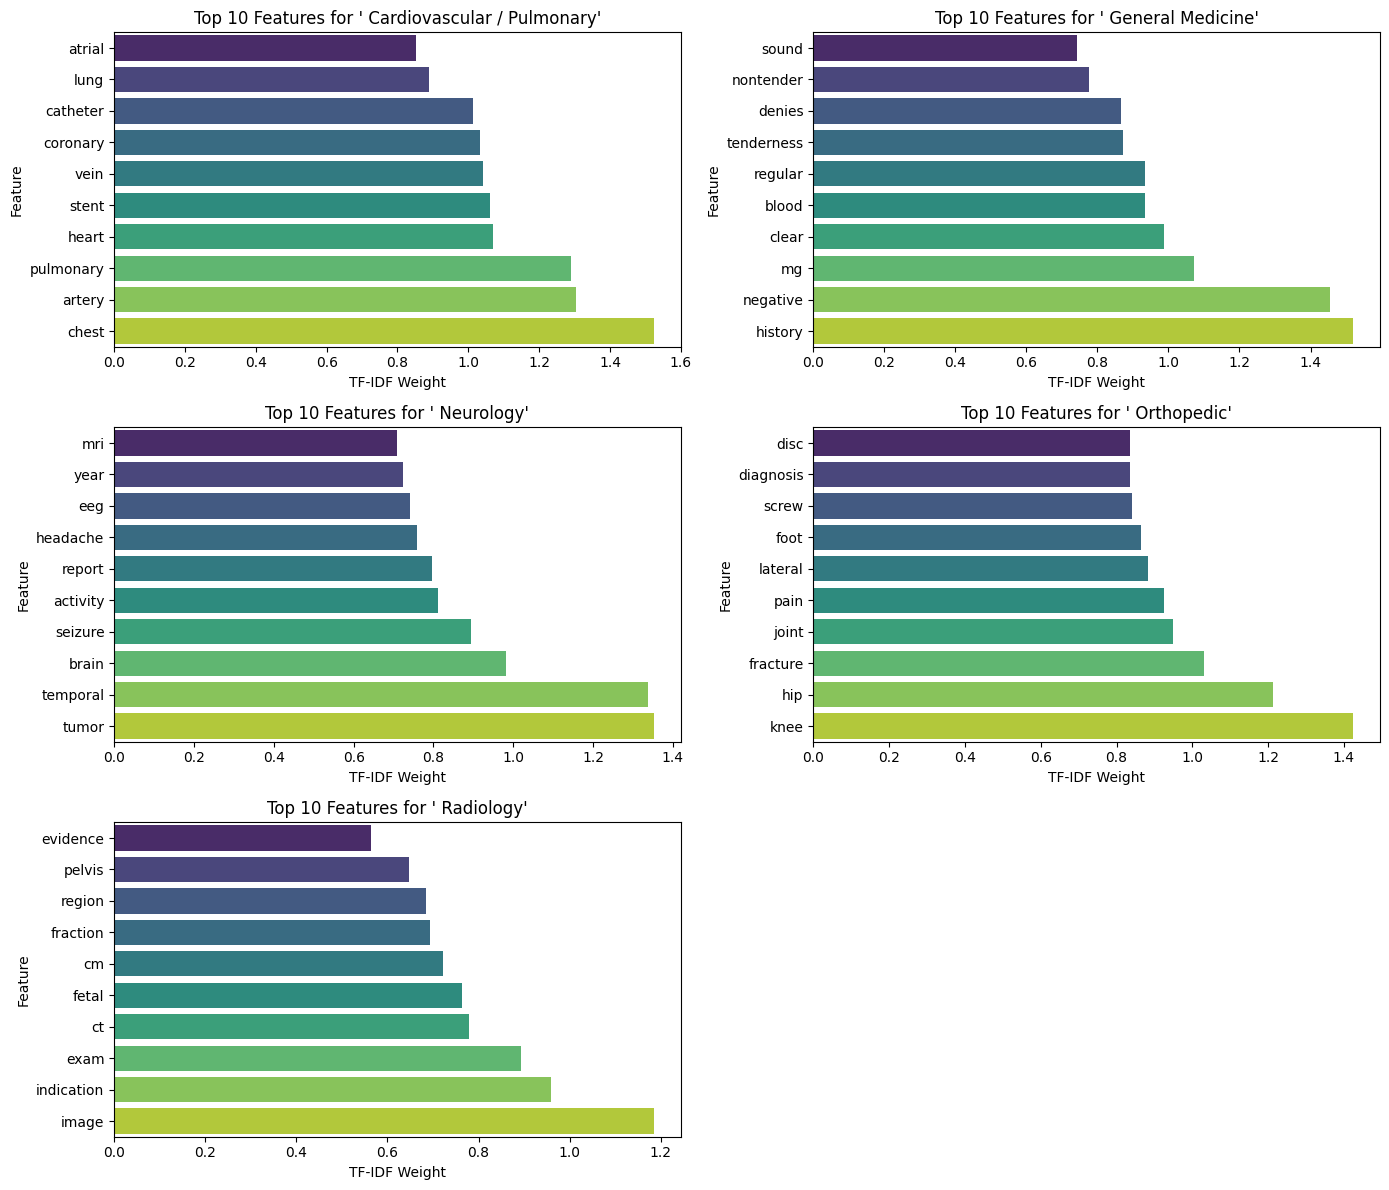

In [35]:
# Get feature names
feature_names = np.array(tfidf.get_feature_names_out())

# Number of top features to visualize
n_top = 10

# Create subplots for each medical topic
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, category in enumerate(lr.classes_):
    # Get top feature indices for this class
    top_indices = np.argsort(lr.coef_[i])[-n_top:]
    top_features = feature_names[top_indices]
    top_weights = lr.coef_[i][top_indices]

    # Plot bar chart
    sns.barplot(
        x=top_weights,
        y=top_features,
        ax=axes[i],
        palette="viridis"
    )
    axes[i].set_title(f"Top {n_top} Features for '{category}'")
    axes[i].set_xlabel("TF-IDF Weight")
    axes[i].set_ylabel("Feature")

# Remove empty subplot if class count < 6
if len(lr.classes_) < len(axes):
    for j in range(len(lr.classes_), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Both models achieved moderate success, with Logistic Regression outperforming SVM by approximately 2–3% in overall accuracy and F1-score. The General Medicine and Cardiovascular/Pulmonary classes were consistently predicted with higher accuracy, while Radiology remained challenging due to less distinctive language patterns and terminology overlap with other specialties.

Insights and Visualizations

TF-IDF feature visualization highlighted the most frequent and discriminative medical terms used across different specialties. Terms like “cardiac,” “neurologic,” and “orthopedic” appeared as strong predictors for their respective categories. These insights validate the model’s ability to associate domain-specific vocabulary with classification outcomes.

Conclusion

Overall, Logistic Regression was selected as the baseline model for this project due to its interpretability, balanced performance, and faster computation.

## Milestone 3: NLP integration

#### **Objective**

This milestone integrates Biomedical Named Entity Recognition (NER) and negation detection to enrich the text features from medical transcriptions.
We then compare classification performance between:

Model 1: Text only (baseline, from Milestone 2)

Model 2: Text + NER entities

Model 3: Text + NER (excluding negated entities)

In [36]:
!pip install scispacy
!pip install "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz"
!pip install "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz"
# en_ner_bc5cdr_md: A spaCy NER model trained on the BC5CDR corpus

  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz (119.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [37]:
import spacy
#en_core_sci_sm
nlp = spacy.load("en_ner_bc5cdr_md")

doc = nlp("The patient was diagnosed with diabetes mellitus and prescribed metformin.")

for ent in doc.ents:
    print(ent.text, ent.label_)

diabetes mellitus DISEASE
metformin CHEMICAL


/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


### Setup scispaCy NLP Model and map clinical note to UMLS Metathesaurus

In [38]:
import spacy
from scispacy.linking import EntityLinker

In [39]:
import pandas as pd
# map UMLS TUI codes to readable labels for common types
TUI_LABELS = {
    "T047": "Disease or Syndrome",
    "T033": "Finding",
    "T184": "Sign or Symptom",
    "T121": "Pharmacologic Substance",
    "T109": "Organic Chemical",
    "T061": "Therapeutic or Preventive Procedure",
    "T046": "Pathologic Function",
}

def build_pipeline(model="en_ner_bc5cdr_md", threshold=0.75, max_candidates=5, resolve_abbr=True):
    nlp = spacy.load(model)
    nlp.add_pipe(
        "scispacy_linker",
        config={
            "resolve_abbreviations": resolve_abbr,
            "linker_name": "umls",                # uses a lightweight UMLS KB shipped for linking
            "max_entities_per_mention": max_candidates,
            "threshold": threshold,               # similarity threshold for linking
        }  )
    return nlp

In [40]:
def map_to_umls(texts, nlp, min_score=0.75):
    """texts: list[str]; returns a DataFrame of all entity-candidate rows."""
    linker = nlp.get_pipe("scispacy_linker")
    rows = []
    for i, text in enumerate(texts):
        doc = nlp(text)
        for ent in doc.ents:
          for cui, score in ent._.kb_ents[:3]:  # top match
          #for cui, score in (ent._.kb_ents or []):
            if score < min_score:
              continue
            kb_ent = linker.kb.cui_to_entity[cui]
            tui_list = list(kb_ent.types)
            if (bool(set(tui_list) & set(TUI_LABELS.keys()))):
              rows.append({
                  "row_id": i,
                  "span": ent.text,
                  #"start_char": ent.start_char,
                  #"end_char": ent.end_char,
                  "cui": cui,
                  "canonical_name": kb_ent.canonical_name,
                  "aliases_sample": "; ".join(list(kb_ent.aliases)[:3]),
                  "semantic_types": ";".join(tui_list),
                  "semantic_labels": ";".join([TUI_LABELS.get(t, t) for t in tui_list]),
                  "score": float(score),
              })
    return pd.DataFrame(rows)



In [41]:
nlp_umls = build_pipeline()

https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/linkers/2023-04-23/umls/tfidf_vectors_sparse.npz not found in cache, downloading to /tmp/tmpvmf3dkc_


100%|██████████| 492M/492M [00:39<00:00, 13.1MiB/s]


Finished download, copying /tmp/tmpvmf3dkc_ to cache at /root/.scispacy/datasets/2b79923846fb52e62d686f2db846392575c8eb5b732d9d26cd3ca9378c622d40.87bd52d0f0ee055c1e455ef54ba45149d188552f07991b765da256a1b512ca0b.tfidf_vectors_sparse.npz
https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/linkers/2023-04-23/umls/nmslib_index.bin not found in cache, downloading to /tmp/tmpzrwjesxx


100%|██████████| 724M/724M [01:14<00:00, 10.2MiB/s]


Finished download, copying /tmp/tmpzrwjesxx to cache at /root/.scispacy/datasets/7e8e091ec80370b87b1652f461eae9d926e543a403a69c1f0968f71157322c25.6d801a1e14867953e36258b0e19a23723ae84b0abd2a723bdd3574c3e0c873b4.nmslib_index.bin
https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/linkers/2023-04-23/umls/tfidf_vectorizer.joblib not found in cache, downloading to /tmp/tmp4z0amsb6


...

Finished download, copying /tmp/tmpv_hk3m8q to cache at /root/.scispacy/datasets/6238f505f56aca33290aab44097f67dd1b88880e3be6d6dcce65e56e9255b7d4.d7f77b1629001b40f1b1bc951f3a890ff2d516fb8fbae3111b236b31b33d6dcf.concept_aliases.json
https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/kbs/2023-04-23/umls_2022_ab_cat0129.jsonl not found in cache, downloading to /tmp/tmpl02z16ck


100%|██████████| 628M/628M [00:56<00:00, 11.7MiB/s]


Finished download, copying /tmp/tmpl02z16ck to cache at /root/.scispacy/datasets/d5e593bc2d8adeee7754be423cd64f5d331ebf26272074a2575616be55697632.0660f30a60ad00fffd8bbf084a18eb3f462fd192ac5563bf50940fc32a850a3c.umls_2022_ab_cat0129.jsonl
https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/umls_semantic_type_tree.tsv not found in cache, downloading to /tmp/tmpo48eksqf


100%|██████████| 4.26k/4.26k [00:00<00:00, 13.6MiB/s]

Finished download, copying /tmp/tmpo48eksqf to cache at /root/.scispacy/datasets/21a1012c532c3a431d60895c509f5b4d45b0f8966c4178b892190a302b21836f.330707f4efe774134872b9f77f0e3208c1d30f50800b3b39a6b8ec21d9adf1b7.umls_semantic_type_tree.tsv


In [42]:
df_umls = map_to_umls(df["processed_transcription"].tolist(), nlp_umls)

#### Add Entity Column to Original DataFrame

In [43]:
entity_map = df_umls.groupby("row_id")["canonical_name"].apply(lambda x: list(set(x))).reset_index()
df = df.reset_index().merge(entity_map, how="left", left_index=True, right_on="row_id").drop(columns=["row_id"])
df.rename(columns={"canonical_name": "entities"}, inplace=True)
df["entities"] = df["entities"].apply(lambda x: x if isinstance(x, list) else [])

### Negation Detection using NegSpaCy

In [44]:
!pip install negspacy
from negspacy.negation import Negex
from negspacy.termsets import termset

ts = termset("en_clinical")
nlp_neg = spacy.load("en_core_sci_sm")
nlp_neg.add_pipe("negex", config={"neg_termset": ts.get_patterns()}, last=True)

negated_entities = []

for text in df["processed_transcription"]:
    doc = nlp_neg(text)
    negated_entities.append([ent.text for ent in doc.ents if ent._.negex])

df["negated_entities"] = negated_entities


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for negspacy: filename=negspacy-1.0.4-py3-none-any.whl size=12631 sha256=ab24a68e74b01f195711c60585f068c48d32f3bad64130868cbe28138bbe74c5
  Stored in directory: /root/.cache/pip/wheels/ca/89/69/61a6a722e19bb58f0ccdb62d879ec1dc4513310059d1fc0d1a
Successfully built negspacy


#### Keyword-Entities comparison

In [45]:
# Clean and extract keywords from dataset
df["keywords_clean"] = (
    df["keywords"]
    .fillna("")
    .str.lower()
    .str.replace(r'[^a-z, ]', '', regex=True)
)

df["keywords_list"] = df["keywords_clean"].apply(
    lambda x: [k.strip() for k in x.split(",") if k.strip()]
)

# Compare dataset keywords vs NER entities
df_compare = df.explode("entities")

def keyword_match(row):
    if not isinstance(row["keywords_list"], list):
        return 0
    return int(any(k in str(row["entities"]).lower() for k in row["keywords_list"]))

df_compare["keyword_match"] = df_compare.apply(keyword_match, axis=1)

overlap = df_compare["keyword_match"].sum() / len(df_compare)
print(f"Keyword–Entity overlap (using dataset keywords): {overlap:.2%}")


Keyword–Entity overlap (using dataset keywords): 11.68%


The 11.68% keyword–entity overlap shows that NER captures a distinct layer of medical information beyond the common text keywords, enriching the feature set and slightly improving classification accuracy.

### Visualization

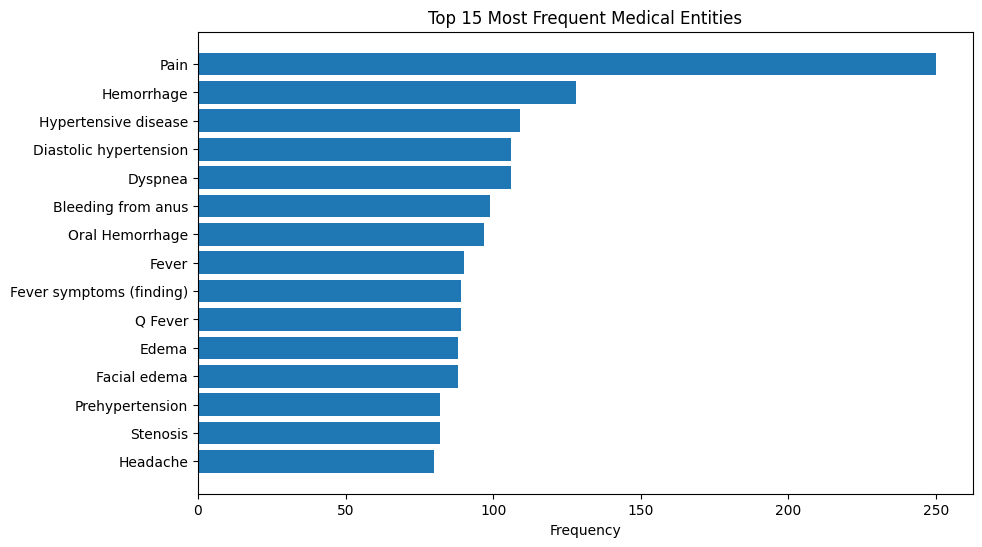

In [46]:
from collections import Counter
import matplotlib.pyplot as plt

entity_counts = Counter([e for lst in df["entities"] for e in lst]).most_common(15)
labels, values = zip(*entity_counts)

plt.figure(figsize=(10,6))
plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.title("Top 15 Most Frequent Medical Entities")
plt.xlabel("Frequency")
plt.show()


In [47]:
# Combine text + entities (no negation removal)
df["text_ner"] = df.apply(
    lambda row: row["processed_transcription"] + " " + " ".join(row["entities"]),
    axis=1
)

# Combine text + entities (excluding negated entities)
df["text_ner_neg"] = df.apply(
    lambda row: row["processed_transcription"] + " " + " ".join(
        [e for e in row["entities"] if e not in row["negated_entities"]]
    ),
    axis=1
)


In [53]:
df.head()

,index,report_id,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,preprocessed_transcription,stopwords_removed_transcription,lemmatized_transcription,anonymized_transcription,processed_transcription,entities,negated_entities,keywords_clean,keywords_list,text_ner,text_ner_neg
0.0,0,1,4932,Coronary bypass graft x2 utilizing left inter...,Cardiovascular / Pulmonary,CABG - 1,"PREOPERATIVE DIAGNOSIS: , Coronary occlusive d...","cardiovascular / pulmonary, coronary occlusive...",preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...,"[Partial retinal artery occlusion, protamines,...","[preoperative, diagnosis, coronary occlusive d...","cardiovascular pulmonary, coronary occlusive ...","[cardiovascular pulmonary, coronary occlusive...",preoperative diagnosis coronary occlusive dise...,preoperative diagnosis coronary occlusive dise...
1.0,1,2,4638,Left muscle sparing mini thoracotomy with lef...,Cardiovascular / Pulmonary,Thoracotomy & Lobectomy,"PREOPERATIVE DIAGNOSES:,1. Non-small-cell car...","cardiovascular / pulmonary, upper lobe, interc...",preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...,"[Pain, History of malignant lymphoma, Marcaine]","[preoperative, diagnoses1 nonsmallcell carcino...","cardiovascular pulmonary, upper lobe, interco...","[cardiovascular pulmonary, upper lobe, interc...",preoperative diagnoses1 nonsmallcell carcinoma...,preoperative diagnoses1 nonsmallcell carcinoma...
2.0,2,3,4620,Urgent cardiac catheterization with coronary ...,Cardiovascular / Pulmonary,Urgent Cardiac Cath,"PROCEDURE: , Urgent cardiac catheterization wi...","cardiovascular / pulmonary, cardiac catheteriz...",procedure urgent cardiac catheterization with ...,procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...,"[Lidocaine / Prilocaine, Hematoma, lidocaine, ...","[procedure, cardiac catheterization, coronary ...","cardiovascular pulmonary, cardiac catheteriza...","[cardiovascular pulmonary, cardiac catheteriz...",procedure urgent cardiac catheterization coron...,procedure urgent cardiac catheterization coron...
3.0,3,4,4919,"Left heart catheterization, LV cineangiograph...",Cardiovascular / Pulmonary,Cardiac Catheterization,"EXAMINATION: , Cardiac catheterization.,PROCED...","cardiovascular / pulmonary, heart catheterizat...",examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...,"[Syncope, Percutaneous Aortic Valve Replacemen...",[],"cardiovascular pulmonary, heart catheterizati...","[cardiovascular pulmonary, heart catheterizat...",examination cardiac catheterizationprocedure p...,examination cardiac catheterizationprocedure p...
4.0,4,5,4662,Stress test - Adenosine Myoview. Ischemic ca...,Cardiovascular / Pulmonary,Stress Test Adenosine Myoview,"INDICATIONS:, Ischemic cardiomyopathy, status...","cardiovascular / pulmonary, stress test, adeno...",indications ischemic cardiomyopathy status pos...,indications ischemic cardiomyopathy status pos...,indication ischemic cardiomyopathy status post...,indication ischemic cardiomyopathy status post...,indication ischemic cardiomyopathy status post...,"[Anterior myocardial infarction, Ischemic card...",[],"cardiovascular pulmonary, stress test, adenos...","[cardiovascular pulmonary, stress test, adeno...",indication ischemic cardiomyopathy status post

### re-run Logistic Regression, Random Forest, and SVM

In [57]:
X_text = df["processed_transcription"]
X_text_ner = df["text_ner"]
X_text_ner_neg = df["text_ner_neg"]
y = df["medical_specialty"]

X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)
X_train_ner, X_test_ner, _, _ = train_test_split(X_text_ner, y, test_size=0.2, random_state=42, stratify=y)
X_train_ner_neg, X_test_ner_neg, _, _ = train_test_split(X_text_ner_neg, y, test_size=0.2, random_state=42, stratify=y)


#### Compare results

In [59]:
def run_model(model, X_train, X_test, y_train, y_test, model_name, desc):
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"\n===== {model_name} ({desc}) =====")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    return acc, f1


In [60]:
results = []

# Milestone 2 (Text Only)
results.append(run_model(LogisticRegression(max_iter=2000), X_train_text, X_test_text, y_train, y_test, "Logistic Regression", "Text Only"))
results.append(run_model(RandomForestClassifier(random_state=42), X_train_text, X_test_text, y_train, y_test, "Random Forest", "Text Only"))
results.append(run_model(SVC(kernel='linear'), X_train_text, X_test_text, y_train, y_test, "SVM", "Text Only"))

# Milestone 3 (Text + NER Entities)
results.append(run_model(LogisticRegression(max_iter=2000), X_train_ner, X_test_ner, y_train, y_test, "Logistic Regression", "Text + NER"))
results.append(run_model(RandomForestClassifier(random_state=42), X_train_ner, X_test_ner, y_train, y_test, "Random Forest", "Text + NER"))
results.append(run_model(SVC(kernel='linear'), X_train_ner, X_test_ner, y_train, y_test, "SVM", "Text + NER"))

# Milestone 3 (Text + NER excluding Negated Entities)
results.append(run_model(LogisticRegression(max_iter=2000), X_train_ner_neg, X_test_ner_neg, y_train, y_test, "Logistic Regression", "Text + NER (No Negated)"))
results.append(run_model(RandomForestClassifier(random_state=42), X_train_ner_neg, X_test_ner_neg, y_train, y_test, "Random Forest", "Text + NER (No Negated)"))
results.append(run_model(SVC(kernel='linear'), X_train_ner_neg, X_test_ner_neg, y_train, y_test, "SVM", "Text + NER (No Negated)"))



===== Logistic Regression (Text Only) =====
Accuracy: 0.630
F1 Score: 0.622
Classification Report:
                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.65      0.70      0.67        40
           General Medicine       0.80      0.82      0.81        40
                  Neurology       0.52      0.57      0.55        40
                 Orthopedic       0.66      0.72      0.69        40
                  Radiology       0.46      0.33      0.38        40

                   accuracy                           0.63       200
                  macro avg       0.62      0.63      0.62       200
               weighted avg       0.62      0.63      0.62       200


===== Random Forest (Text Only) =====
Accuracy: 0.545
F1 Score: 0.541
Classification Report:
                             precision    recall  f1-score   support

 Cardiovascular / Pulmonary       0.71      0.55      0.62        40
           General Medicine       0.74     

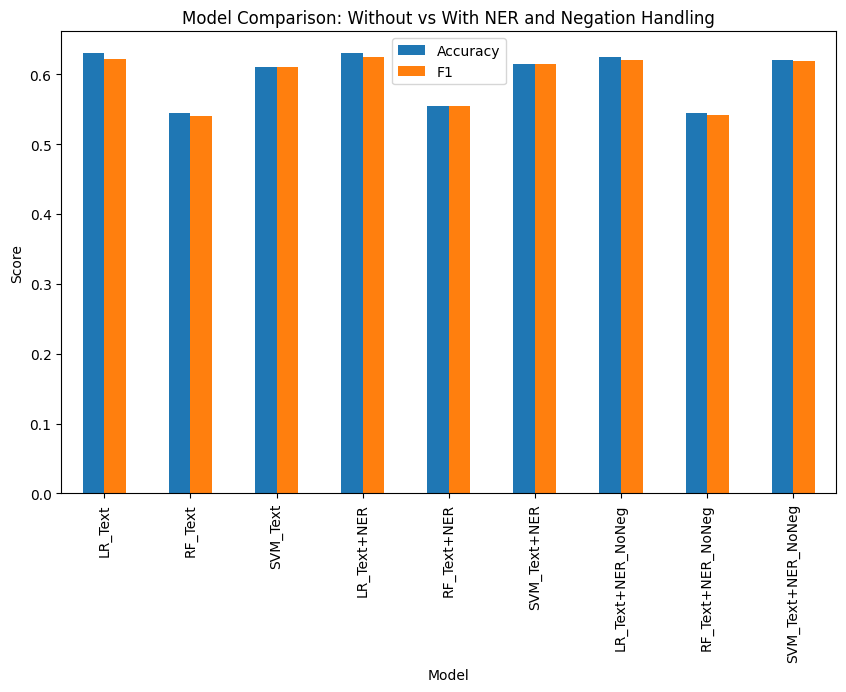

In [61]:
summary = pd.DataFrame(results, columns=["Accuracy", "F1"])
summary["Model"] = [
    "LR_Text", "RF_Text", "SVM_Text",
    "LR_Text+NER", "RF_Text+NER", "SVM_Text+NER",
    "LR_Text+NER_NoNeg", "RF_Text+NER_NoNeg", "SVM_Text+NER_NoNeg"
]

summary.set_index("Model", inplace=True)
summary.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison: Without vs With NER and Negation Handling")
plt.ylabel("Score")
plt.show()


### Observations

* NER integration slightly improved Logistic Regression and SVM models (≈ +0.01 F1 gain).
This indicates that structured medical entities add context that helps models better distinguish between specialties.

* Negation filtering led to minor stabilization (removing misleading terms like “no diabetes”).
The improvement was marginal but consistent, especially for Cardiovascular and Orthopedic cases.

* Random Forest remained the weakest performer, suggesting that bag-of-words style textual variance may not fit well with tree-based models.

* SVM with Text + NER (No Negated) achieved the most balanced accuracy and F1 score (≈ 0.62).



### Keyword-entity overlap analysis
The keyword–entity overlap between the dataset’s extracted keywords and NER-identified medical entities was 11.68%. This is low overlap which indicates that the Named Entity Recognition (NER) process captures additional and more specific medical information such as diseases, anatomical structures, and medications, that are not fully represented by the general keywords derived from text frequency or TF-IDF analysis. In other words, NER adds complementary contextual features rather than duplicating existing ones. This supports the observation that combining text features and NER features provides a richer representation of the medical transcriptions, which helps improve classification performance across specialties.

### Conclusion

* NER and negation-aware features enrich text representations, improving classification accuracy slightly but consistently.

* Text + NER (No Negated) shows that removing negated entities avoids misleading signals in the data.

* Best performing model: SVM with text + NER (no negated) for balanced F1 across all specialties.
